In [8]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import ast
import statsmodels.api as sm
from sklearn.metrics import (confusion_matrix, 
                           accuracy_score)
import scipy.stats as stats

import _syntax_score_helper_function as ga
import _helper_grammar_functions as jsgo
from _helper_functions import *

In [2]:
# load syntax features
fn='F05-Syntax-Features/6-real-and-imputed-motifs.pd.df.pickle'
syndf=pd.read_pickle(fn)#.set_index('phrase-key')

syndf.head(2)

,phrase-length,func-odds-ratio,real-data,hyp-func-p-bonf,num-total-seqs,num-active-ens,obs-or-imputed
phrase-key,,,,,,,
ord_ori_spc=g_21_e_24_E,3.0,11.206427,"(63, 34, 7)",3.246130e-29,104.0,63.0,obs
ord_ori_spc=g_13_e_24_E,3.0,8.385350,"(108, 73, 21)",3.208155e-43,202.0,108.0,obs


In [3]:
sigmotifset=set(syndf.index)
list(sigmotifset)[:10]

['ord_ori_spc=g_8_g_23_e',
 'ord_ori_spc=g_27_G_8_g',
 'ord_ori_spc=g_45_G',
 'ord_ori_spc=G_20_E_7_G',
 'ord_ori_spc=g_8_g_37_E',
 'ord_ori_spc=g_37_g_15_E',
 'ord_ori_spc=g_8_e_44_g',
 'ord_ori_spc=E_13_G_20_g',
 'ord_ori_spc=g_52_E',
 'ord_ori_spc=g_8_g_42_e']

In [4]:
sigmotifset_withrevcomp=set()

for si in sigmotifset:

    
    resi=ga.revcomp(si.split('=')[-1],'ord_ori_spc')
    resi='ord_ori_spc='+resi

    sigmotifset_withrevcomp.add(si)
    sigmotifset_withrevcomp.add(resi)


In [5]:
# get activity of all variants
fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
mpradf=pd.read_pickle(fn)

mpradf.head(1)

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
0,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0



# Mapping each element to the syntax features contained within it

In [7]:
# If running for the first time

# structure for data collected
syn2en2afflist={}
en2syn2afflist={}

# options for encoding syntax
spacing=True

for length in [2,3]:
    for seq in mpradf['wt-enhancer-seq']:
    
        # get full sentence
        sentence_oos =ga.get_sentence_from_seq(seq,featureTuple=('ord','ori','spc'))
        sentence_oosa=ga.get_sentence_from_seq(seq,featureTuple=('ord','ori','spc','aff'))
        
        # get all possible features with and without affinty 
        allPossibleFeatures_tuplelist_oos=list(ga.get_all_phrases(sentence_oos,spacing,length).keys())
        allPossibleFeatures_tuplelist_oosa=list(ga.get_all_phrases(sentence_oosa,spacing,length).keys())
        
        ### map affinity of each site
        # for all features with and without affinity encoding 
        for oosai in allPossibleFeatures_tuplelist_oosa:

            # strip affinity
            oosi=[]
            for i in oosai:
                if type(i)==str:
                    i=i.split('.')[0]
                    oosi.append(i)
                else:
                    oosi.append(i)
            oosi=tuple(oosi)
            
            if oosi not in syn2en2afflist:
                syn2en2afflist[oosi]={}
            if seq not in en2syn2afflist:
                en2syn2afflist[seq]={}
        
            syn2en2afflist[oosi][seq]=[]
            en2syn2afflist[seq][oosi]=[]
        
            # for each site
            for si,sai in zip(oosi,oosai):
                
                # skip if spacing 
                if type(si)==int: continue
        
                # ensure the affinity encoding is associated with the same motif
                sai_noaff,sai_affonly=sai.split('.')
                
                if si!=sai_noaff: 
                    print(length,si,sai_noaff)
                    print(oosi)
                    print(oosai)
                    raise ValueError('123')
        
                # map affinity
                syn2en2afflist[oosi][seq].append(sai_affonly)
                en2syn2afflist[seq][oosi].append(sai_affonly)

# write the data
for d,name in [(syn2en2afflist,'F05-Syntax-Features//syn2en2afflist.pydict.pickle'),(en2syn2afflist,'F05-Syntax-Features//en2syn2afflist.pydict.pickle')]:
    with open(name,'wb') as f:
        pickle.dump(d,f,protocol=pickle.HIGHEST_PROTOCOL)

In [9]:
syn2en2afflist=load_pickle_dict('F05-Syntax-Features/syn2en2afflist.pydict.pickle')
en2syn2afflist=load_pickle_dict('F05-Syntax-Features/en2syn2afflist.pydict.pickle')

# Reference Information

In [10]:
fn='reference-files//OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)


In [11]:
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Name=pickle.load(f)


In [12]:
fn='reference-files//SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)
    

In [15]:
fn='F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters=100.pd.df.pickle'
sdf=pd.read_pickle(fn).set_index('syntax-family',drop=False)
sdf.loc[:,'n-func-inert-tuple']=sdf.loc[:,'n-func-inert-tuple'].apply(lambda i: ast.literal_eval(i))
sdf.head(1)

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
syntax-family,,,,,,,,,,,,,,,,,,,,,
L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,4,2,"(4, 2)","(2, 3)","(2, 5)","(4, 3)","(3, 3)","(1, 6)","(2, 4)",...,"(0, 3)","(4, 2)","(2, 3)","(3, 2)","(5, 2)","(4, 2)","(1, 6)","(1, 3)","(1, 1)","(1, 6)"


In [16]:
mpradf['bin']=mpradf['enhancer-sites'].apply(lambda sites: sdf.at[OLSName2SyntaxFamily[sites],'n-func-inert-tuple'])


In [17]:
fn='reference-files/syntax-fam-Bin2Annotation.pydict.pickle'
with open(fn,'rb') as f:
    Bin2Annotation=pickle.load(f)

In [18]:
mpradf['bin-annotation']=mpradf['bin'].apply(lambda b: Bin2Annotation[b])

# Average number of syntax features in each syntax family group

In [19]:
fn='F05i-Syntax-Scores/3i-all-seqs.fillNaN.funcAnnotationCol=activity-label.effectSize=odds-ratio.pandas.dataframe.pickle'
sdf=pd.read_pickle(fn)
sdf.head()

,Ma,Ma-sum,Ma-sum-nafill1
seq,,,
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGGAAGTTTTCGAAGAGATAACA,[1.4241394089768973],1.424139,1.424139
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACGGAAGTTTTCGAAGTTATCTCA,[1.4241394089768973],1.424139,1.424139
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTTCCGTTTTCGAAGAGATAACA,"[1.188727922167361, 2.039352150059302, 2.05631...",7.723005,7.723005
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCACTTCCGTTTTCGAAGTTATCTCA,[1.188727922167361],1.188728,1.188728
AAGATAGGCATCTGAAGCTCAAGGAAATTAAATATCTTGCTCGAGATAACTTTCGAAACGGAAGTA,[nan],NaN,1.000000


In [20]:
binanno2numsyntaxfeats={}
for enid,en,binanno in zipdf(mpradf,['enhancer-id','wt-enhancer-seq','bin-annotation']):

    

    allsyntaxfeats=sdf.at[en,'Ma']

    if binanno not in binanno2numsyntaxfeats:
        binanno2numsyntaxfeats[binanno]=[]

    binanno2numsyntaxfeats[binanno].append(len(allsyntaxfeats))


In [21]:
for i in [binanno2numsyntaxfeats[bi] for bi in ['Inert','Moderate','Robust']]:
    print(np.median(i))

2.0
3.0
10.0


Text(0, 0.5, 'Number of significant \nsyntax features')

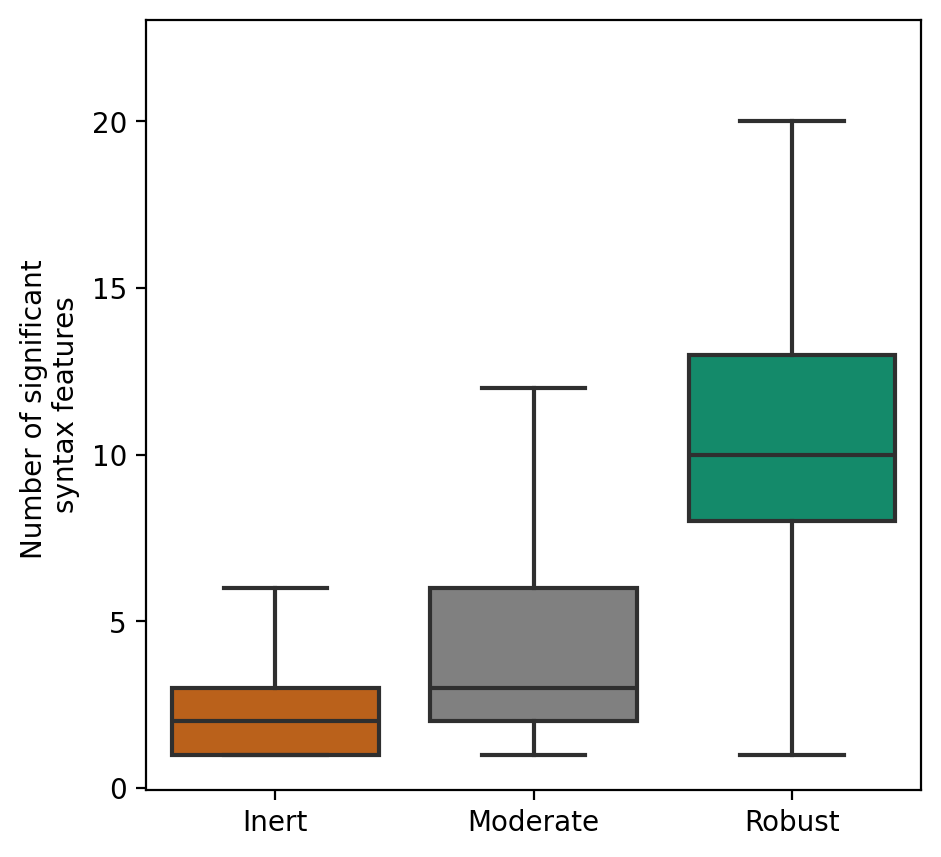

In [23]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

sns.boxplot(data=[binanno2numsyntaxfeats[bi] for bi in ['Inert','Moderate','Robust']],palette=[cb['red'],'grey',cb['green']],fliersize=0)

ax.set_xticklabels(['Inert','Moderate','Robust'])
ax.set_ylabel('Number of significant \nsyntax features')

In [24]:
stats.mannwhitneyu(binanno2numsyntaxfeats['Inert'],binanno2numsyntaxfeats['Moderate'])

MannwhitneyuResult(statistic=2060824733.0, pvalue=0.0)

In [25]:
stats.mannwhitneyu(binanno2numsyntaxfeats['Moderate'],binanno2numsyntaxfeats['Robust'])

MannwhitneyuResult(statistic=225274230.0, pvalue=0.0)

# Average syntax score in each syntax family group

In [26]:
binanno2numsyntaxscores={}
for enid,en,binanno in zipdf(mpradf,['enhancer-id','wt-enhancer-seq','bin-annotation']):

    if binanno not in binanno2numsyntaxscores:
        binanno2numsyntaxscores[binanno]=[]

    binanno2numsyntaxscores[binanno].append(sdf.at[en,'Ma-sum-nafill1'])


In [27]:
for i in [binanno2numsyntaxscores[bi] for bi in ['Inert','Moderate','Robust']]:
    print(np.median(i))

2.4096014991513055
4.901567615206011
19.518602409544282


(-1.0, 50.0)

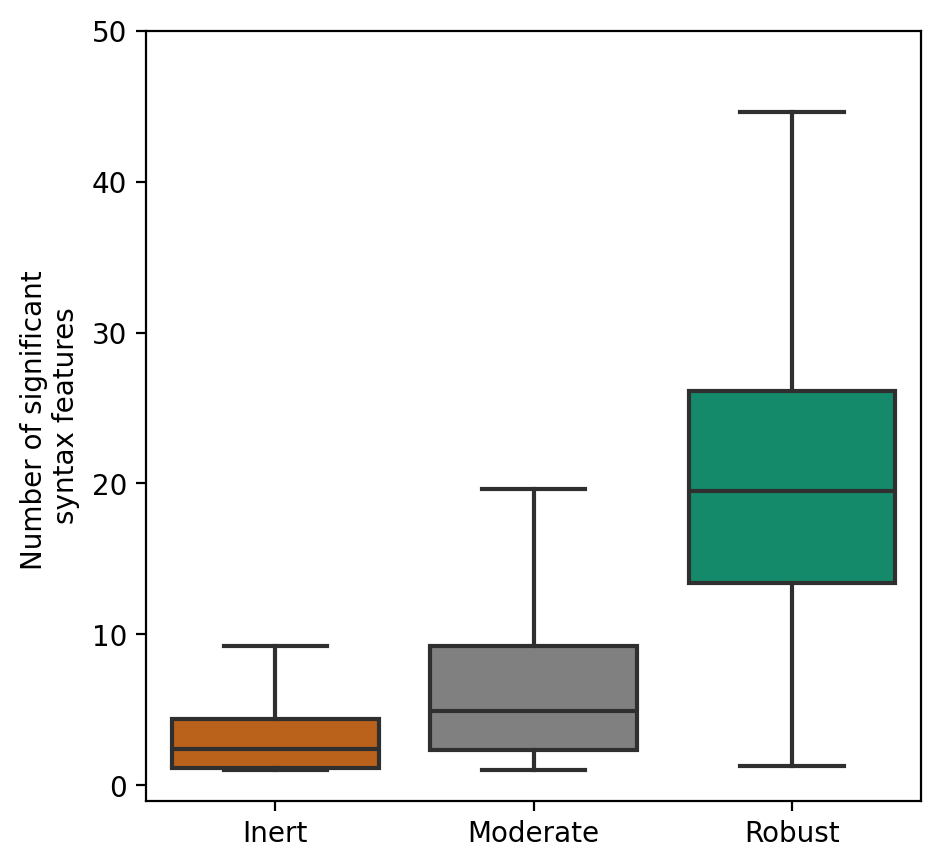

In [29]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

sns.boxplot(data=[binanno2numsyntaxscores[bi] for bi in ['Inert','Moderate','Robust']],palette=[cb['red'],'grey',cb['green']],fliersize=0)

ax.set_xticklabels(['Inert','Moderate','Robust'])
ax.set_ylabel('Number of significant \nsyntax features')

ax.set_ylim(-1,50)

In [30]:
stats.mannwhitneyu(binanno2numsyntaxscores['Inert'],binanno2numsyntaxscores['Moderate'])

MannwhitneyuResult(statistic=2011546599.0, pvalue=0.0)

In [31]:
stats.mannwhitneyu(binanno2numsyntaxscores['Moderate'],binanno2numsyntaxscores['Robust'])

MannwhitneyuResult(statistic=216124629.5, pvalue=0.0)